In [ ]:
# 데이터 시각화
# 데이터 시각화를 위해선 우선 데이터의 종류를 먼저 이해하는 것이 중요

# 1. 수치형 데이타 => 사칙연산 가능
#  - 연속형 실수형태 (키, 몸무게)
#  - 이산형 정수형태 (A반 학생수 , 인원수)

# 2. 범주형 데이터 => 사칙연산 불가
#  - 순서형  순서있음    학점, 설문조사 점수
#  - 명목형  순서없음    성별, 우편번호

# 명목형 → 막대그래프, 파이차트, Countplot
# 순서형 → 정렬된 막대그래프
# 수치형 → 히스토그램, 박스플롯

# ===================================================

# 막대 → 선 → 히스토그램 → 박스플롯 → 산점도 → 히트맵 순서로 이해

# 실무에서 가장 많이 쓰는 TOP 10
# 막대그래프 → 비교
# 선그래프 → 추세
# 산점도 → 관계
# 히스토그램 → 분포(구간별 단변량)
# 박스플롯 → 이상치
# 히트맵 → 상관관계
# 누적막대 → 구성비
# 파이차트 → 비율
# 트리맵 → 계층
# 산점도 + 회귀선 → 예측

# 한 줄 규칙

# 비교 → 막대 (범주(카테고리)끼리 크기를 비교)
# 변화 → 선
# 관계 → 산점도
# 분포 → 히스토그램
# 비율 → 파이
# 상관 → 히트맵

# 자주 쓰는 plt
# | 코드              | 의미    |
# | --------------- | ----- |
# | `plt.figure()`  | 그림 생성 |
# | `plt.plot()`    | 선그래프  |
# | `plt.bar()`     | 막대그래프 |
# | `plt.scatter()` | 산점도   |
# | `plt.hist()`    | 히스토그램 |
# | `plt.pie()`     | 파이차트  |
# | `plt.title()`   | 제목    |
# | `plt.xlabel()`  | x축    |
# | `plt.ylabel()`  | y축    |
# | `plt.grid()`    | 격자    |
# | `plt.show()`    | 출력    |

In [ ]:
import os

if not os.path.exists("/content/NanumGothic.ttf"):
    !wget -O /content/NanumGothic.ttf \
    https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 등록
font_path = "/content/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(
    fname=font_path
).get_name()

plt.rc("font", family=font_name)

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# warning 안나오게
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# 1. Seaborn은 Python의 데이터 시각화 라이브러리로, 
#  matplotlib을 기반으로 하고 있지만, 더 직관적이고 고급스러운 그래프를 그릴 수 있도록 도와주는 도구
# 2. 통계적 시각화에 특화
# 3. Seaborn은 pandas DataFrame과의 통합이 매우 잘 되어 있어서, pandas에서 직접 데이터를 처리한 뒤 Seaborn으로 바로 시각화
# 4. Seaborn은 기본적으로 아름다운 색상 팔레트와 디자인을 제공


# 수치형 1개
# - 히스토그램   sns.histplot() ,plt.hist() 
# - 분포도 sns.diplot()
# - 박스플롯 sns.boxplot()

# 수치형 2개 이상(변수 관계 확인)
# - 히트맵 sns.heatmap() = 변수관 상관계수 확인
# - 라인플롯 sns.linplot()
# - 산점도 sns.scatterplot()
# - 페어프롯 sns.pairplot()

# 범주형 

# 범주형 1개
# - 카운트 플롯 sns.countplot() => 히스토그램

# 범주형 2개 이상(변수 관계 확인)
# - 막대그래프  sns.barplot()
# - 포인트플롯  sns.pointplot()
# - 박스플롯    sns.boxplot()
# - 바이올린 플롯 sns.violinplot()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# 시각화를 통한 EDA(탐색적 분석)

df_tips = sns.load_dataset("tips")

df_tips.info()

#분석 = 인사이트 도출 
# 1. tips 데이타는 7 개의 컬럼으로 이루어져 있다.
# 2. 3개의 수치형 데이터 와 4개의 범주형 데이터 
# 3. 결측치는 없으며, 244개의 행으로 이루어져 있다.

print(df_tips.head(20))


In [ ]:
# df_tips.to_excel("tips_all.xlsx",index=False)

df_tips.to_excel(
    r"C:\Users\AI융합_데이터분석B\Downloads\tips_all.xlsx",
    index=False
)
# df_tips.to_excel("tips_all.xlsx", index=False)
# import os
# print(os.getcwd()) 

# from google.colab import files
# files.download("tips_all.xlsx")

In [ ]:
# 분석상 total_bill 과 tips 가 가장 중요한 컬럼으로 인식됨
# tips["total_bill"] 히스토그램을 Seaborn으로 그리기

sns.histplot(data=df_tips,x="total_bill",bins=20)

plt.xlabel("Total Bill")
plt.ylabel("Probability Density")
plt.title("Seaborn Histogram of Total Bill")
plt.xticks(rotation=45)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 데이터 불러오기
tips = sns.load_dataset("tips")

# 히스토그램 정보
bins = 20
counts, bin_edges, _ = plt.hist(
    tips["total_bill"],
    bins=bins,
    density=False,  # 확률 밀도
    edgecolor='black'
)

# x축 눈금 수동 지정: bin 경계값들을 x축 눈금으로 설정
plt.xticks(np.round(bin_edges, 1), rotation=45)  # 필요하면 회전

plt.xlabel("Total Bill")
plt.ylabel("횟수")
plt.title("Total Bill Histogram (Density)")
plt.tight_layout()
plt.show()

In [ ]:
# 수치로 확인
df_tips["total_bill"].describe()

# 분석 인사이트 도출
# total_bill 최대  50.810000 최소  3.07 평균 19.78 임을 확인 할수 있다.
# 평균과 중위값의 차이가 2달러 정도 차이가 난다.


In [ ]:
# 2. 박스플롯

#박스플롯(Boxplot)
#전체 분포 현황을 직관적으로 보여준다면,
#boxplot은 박스와 수염 모양으로 여러 가지 정보를 알려준다. (최솟값, 최댓값, Q1, Q2(중위수), Q3 값)
#형태는 sns.boxplot(x or y, data)
#데이터의 중심적인 분포를 파악하고, 이상치를 안정적으로 탐지

sns.boxplot(tips["total_bill"])


# ▶ 이상치 판단 기준 (통계적으로)
# 상한 (upper bound): Q3 + 1.5 × IQR # IQR=Q3−Q1  #데이터 집합에서 제3사분위수(Q3)와 제1사분위수(Q1) 간의 차이
# 하한 (lower bound): Q1 - 1.5 × IQR


# 요소	설명
# Q1 (제1사분위수)	하위 25% 지점의 값
# Q2 (중앙값 / Median)	50% 지점의 값, 상자의 중앙 선
# Q3 (제3사분위수)	상위 25% 지점의 값
# IQR (Interquartile Range)	Q3 - Q1
# 하한 (Lower Bound)	Q1 - 1.5 × IQR
# 상한 (Upper Bound)	Q3 + 1.5 × IQR
# 이상치 (Outliers)	상한을 넘거나 하한보다 작은 값 (점으로 표시됨)

# 분석
# 이상치가 보이며 중위값과 평균값 2달러 정도의 차이가 해당 이상치가 원인인 것으로 보인다.


In [ ]:
# 바이올린 플롯

# boxplot 분포는 확인 하기 좋음
# 분산이 어떤지 확인 하기 어려움


#분산을 확인 하기 위한게, 바이올린 그래프임
#sns.violinplot(x="time", y="total_bill",data=df_tips)

sns.violinplot(data=tips, x="total_bill")
plt.show()

In [ ]:
# 페어 플롯

# seaborn 간판 가장 강력한 기능

# 데이터 수치형 변수들의 쌍별 관계를 한눈데 보여주는 시각화 기능
# 자기가 알아서 이산형(size), 연속형(total_bill,tips) 구분해서 히스토그램 및 산점도 각각에 대응해서 그려줌
# 산점도와 히스토그램 그래프를  각 변수 간의 모든 가능한 조합을 2차원 그래프로 그려줌


sns.pairplot(df_tips)

In [ ]:
#3. 수치형 변수 2개 이상 시각화(변수 간 관계 확인)

#히트맵: sns.heatmap()
#라인플롯: sns.lineplot()
#산점도: sns.scatterplot()
#회귀선 + 산점도: sns.regplot()

#1) 히트맵(heatmap)
#보통 히트맵은 수치형 변수들 간의 상관관계를 나타낼 때 자주 사용한다.

#tips 데이터셋의 상관계수를 구해보자. corr() 함수를 사용한다.
#히트맵 예전버전과 에러
#https://twdatastory.tistory.com/entry/tipscorr-ValueError-could-not-convert-string-to-float-No

#피어슨 상관관계 설명
#https://dd0za-1004.tistory.com/46

#공분산의 이해
#https://ds92.tistory.com/124


tip_corr = tips.corr(numeric_only=True) # 피어슨 상관계수
print(tip_corr)

sns.heatmap(tip_corr)
plt.show()

# 분석
# 1. 팁과 전체 금액과는 상관관계가 있으며, size 와는 관계는 있으나 약해 보임
# 절댓값이 1에 가까운 상관계수: 매우 확고한 상관.

In [ ]:
# 라인 플롯

#라인플롯은 두 수치형 데이터 사이의 관계를 선으로 나타낸다.
#주로 x축에는 이산형(discrete) 데이터, y축에는 연속형(continuous) 데이터를 쓸 때 사용한다.
#그 이유는 x값에 따른 y값의 평균값을 선으로 이어주기 때문이다.
#형태는 sns.lineplot(x, y, hue(범주형), data)

#스타일 설정
#style : 'white', 'dark', 'whitegrid', 'darkgrid' 
sns.set_style("darkgrid")

# 두 수치형 데이터 size, tip 간 관계를 시각화
sns.lineplot(x='size',y='tip',data=df_tips)

# 참고로 그림자가 넓다 = 데이터가 많이 흔들린다(분산 큼),
# 그림자가 좁다 = 데이터가 안정적이다(분산 작음) 라고 해석하는 경우가 많습니다.
# 라인은 기본적으로 평균임

#분석
#1.인원수가 증가 할수록 팁도 증가하는 경향이 있다.
#2.변동성이나 이상값도 해당 그래프에서 그림자로 확인 가능
# 그림자(shaded area) 는 보통 신뢰구간(Confidence Interval, CI) 또는 오차 범위

In [ ]:
# x,y 둘다 연속형을 쓰면? 이상 해 짐
sns.lineplot(x='total_bill',y='tip',data=df_tips)

# 분석
# 라인플롯에서 연속형 데이터를 둘다 x,y 축으로 쓰면 안됨(이상해짐)

In [ ]:
# 산점도 
# 주로 x, y축에 모두 연속형 데이터를 넣을 때 자주 사용한다.
# 형태는 sns.scatterplot(x, y, hue(범주형), data)

sns.scatterplot(x="total_bill",y="tip",data=df_tips,hue="sex")

#분석
# 1. 총금액이 많아 질수록 팁도 많아 지는 경향이 있다.
# 2. 성별에 따른 팁은 차이를 구분할수 없다.
# 3. 이상치도 그래프로 확인 가능하다.

In [ ]:
sns.scatterplot(x="size",y="tip",data=df_tips,hue="sex")

#분석
# 1.산점도에서 x축에 범주형 변수도 분석이 가능하다.
# 2.사이즈 3의 팁이 10은 확실히 이상치로 보인다.(여기에서의 해석은 팁은 가끔 많이 받을때도 있다라고 해석)
# 3.식사인원이 많을수록 평균적인 팁 금액이 증가하는 경향은 있으나,  
# 5인 6인은 데이터 부족으로 인하여, 인원수가 커도 팁이 꼭 많지는 않다는 것을 확인 할수 있다.
# 4.범주형이 x축에 있으면, 이상치 확인이 용이하다.

In [ ]:
# 범주형 데이타
sns.countplot(x="day",data=df_tips)

# 분석
# 1.범주형 데이터는 변수 1개 짜리는 countplot 으로 분석 할수 있다.(plt.bar())
# 2.주말에 평일보다 손님이 많은것을 확인 할수 있다.

In [ ]:
sns.countplot(x="smoker",data=df_tips)
# 분석
# 비흡연자가 더 많이 방문했음을 알수 있다.

In [ ]:
sns.countplot(x="sex",data=df_tips)
# 분석
# 남성이 여성보다 더 많이 방문 했음

In [ ]:
#
sns.countplot(x="time",data=df_tips)
# 분석
# 저녁때 점심보다 두배이상 방문 하였음

In [ ]:
# 범주형 그래프 - x,y 처리 그래프

# 막대그래프

# 검은 세로선은 해당 평균의 95% 신뢰구간
# male의 팁 평균이 3.0이고, 검은선이 2.5~3.5라면:
# 실제 평균 팁이 이 범위 안에 있을 확률이 95%다"라는 통계적 의미
sns.barplot(x="sex",y="tip",data=df_tips,hue="day")

<Axes: xlabel='day', ylabel='tip'>

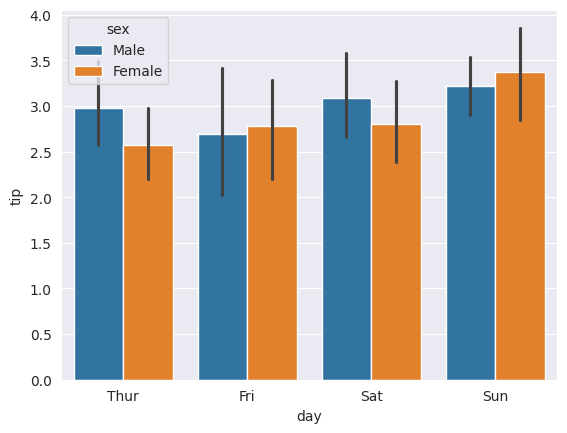

In [ ]:
# 요일별 tip 평균
sns.barplot(x="day",y="tip",data=df_tips,hue="sex")

# 분석
# 주말일수록 팁을 더 내는 경향이 있다.
# 일요일에 남자든 여자든 성별 상관없이 팁을 가장 많이 내었다.

<Axes: xlabel='time', ylabel='total_bill'>

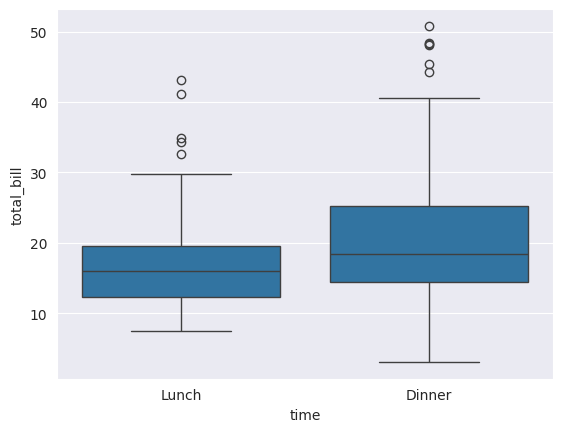

In [ ]:
#  박스 플롯
sns.boxplot(x="time", y="total_bill",data=df_tips)

#분석
# 1. 저녁이 점심보다 더 많이 쓴다
# 2. 점심은 상대적으로 변동성이 작고, 중앙값도 낮다 => 점심은 간단히 저녁은 다양하고 고가로 먹는 경향이 있다.
# 3. 점심 데이터는 중위값 근처에 몰린 데이터가 많다.

#결론
#점심은 간단히 저녁은 다양하고 고가로

<Axes: xlabel='total_bill', ylabel='time'>

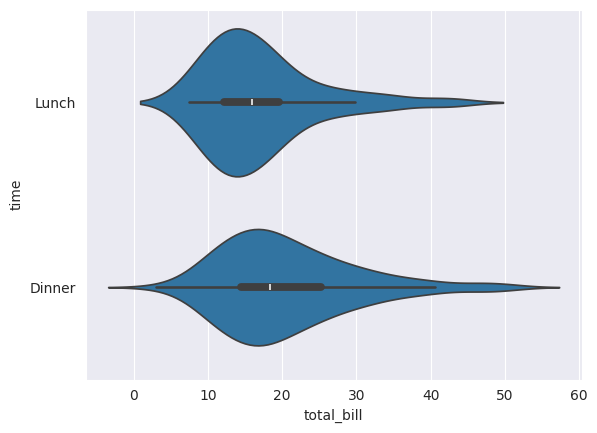

In [113]:
# 바이올린 플롯

# boxplot 분포는 확인 하기 좋음
# 분산이 어떤지 확인 하기 어려움


#분산을 확인 하기 위한게, 바이올린 그래프임
#sns.violinplot(x="time", y="total_bill",data=df_tips)

#분석
# 1.저녁시간의 식사 금액이 전반적으로 크고 다양하다.
# 2.점심은 대체로 저렴하고 균일한 금액이 분포한다.
# 3.저녁식사에 고가 식사가 존재 할수도 있다

#결론
#가장 중위수가 몰린 것은 점심 때임(가운데 쪽으로 볼록 하게 튀어 나왔으므로)

sns.violinplot(x="total_bill", y="time",data=df_tips)